# BTC forecasting benchmark notebook

Compare classical ML, stochastic SDE, and hybrid SDE + ML models on the same BTC dataset, with optional RandomizedSearchCV tuning for ML and hybrid drift models.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import get_data
from src.evaluation.metrics import metrics_frame, regression_metrics
from src.models.elastic_net_model import ElasticNetModel
from src.models.gradient_boosting_model import GradientBoostingModel
from src.models.random_forest_model import RandomForestModel
from src.models.hybrid_model import (
    HybridSDEMLModel,
    HybridSDEElasticNetModel,
    HybridSDERandomForestModel,
)
from src.models.sde_models import GBMModel, MertonJumpDiffusionModel, HestonModel

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
TICKERS = {'BTC-USD': 'BTC'}
INTERVAL = '15m'
START_DATE = '2026-03-15'
END_DATE = '2026-05-15'
HORIZON = 10
DT = 1.0
TEST_SIZE = 0.2
PRICE_LAGS = 10
VOLUME_LAGS = 5
CONTEXT_BARS = 80
N_SDE_PATHS = 500
USE_TUNING = True
TUNING_ITERATIONS = 20
TUNING_CV_SPLITS = 3
TUNING_VERBOSE = 2

In [3]:
def make_supervised_frame(df: pd.DataFrame, horizon: int = 10) -> pd.DataFrame:
    out = df.copy()

    for lag in range(1, PRICE_LAGS + 1):
        out[f'close_lag_{lag}'] = out['BTC_Close'].shift(lag)

    for lag in range(1, VOLUME_LAGS + 1):
        out[f'volume_lag_{lag}'] = out['BTC_Volume'].shift(lag)

    out['high_lag_1'] = out['BTC_High'].shift(1)
    out['low_lag_1'] = out['BTC_Low'].shift(1)
    out['hl_range_lag_1'] = (out['BTC_High'] - out['BTC_Low']).shift(1)
    out['sma_20_lag_1'] = out['BTC_Close'].rolling(20).mean().shift(1)

    delta = out['BTC_Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    out['rsi_14_lag_1'] = (100 - (100 / (1 + rs))).shift(1)
    out['rsi_14_lag_1'] = out['rsi_14_lag_1'].fillna(50.0)

    out['target'] = out['BTC_Close'].shift(-horizon)
    return out.dropna().reset_index(drop=True)


def maybe_tune_tabular_model(model, X_train, y_train):
    if USE_TUNING and hasattr(model, 'tuning_space'):
        print(f'\nTuning {model.model_name}...')
        model.tune(
            X_train,
            y_train,
            param_distributions=model.tuning_space(),
            n_iter=TUNING_ITERATIONS,
            cv_splits=TUNING_CV_SPLITS,
            verbose=TUNING_VERBOSE,
        )
        print('Best params:', model.best_params_)
    else:
        model.fit(X_train, y_train)
    return model


def maybe_tune_hybrid_model(model, train_prices, dt: float):
    if USE_TUNING and hasattr(model, 'tuning_space'):
        print(f'\nTuning {model.model_name}...')
        model.tune(
            train_prices,
            param_distributions=model.tuning_space(),
            dt=dt,
            n_iter=TUNING_ITERATIONS,
            cv_splits=TUNING_CV_SPLITS,
            verbose=TUNING_VERBOSE,
        )
        print('Best params:', model.best_params_)
    else:
        model.fit(train_prices, dt=dt)
    return model


def evaluate_tabular_model(model, X_train, y_train, X_test, y_test) -> tuple[dict, np.ndarray]:
    model = maybe_tune_tabular_model(model, X_train, y_train)
    y_pred = model.predict(X_test)
    return {'model': model.model_name, **regression_metrics(y_test, y_pred)}, y_pred


def evaluate_sde_model(model, train_prices, eval_prices, horizon: int, dt: float, n_paths: int) -> tuple[dict, np.ndarray, np.ndarray]:
    print(f'\nFitting {model.model_name}...')
    model.fit(train_prices, dt=dt)
    y_pred = model.rolling_forecast(eval_prices, horizon=horizon, n_paths=n_paths, dt=dt)
    y_true = eval_prices[horizon:horizon + len(y_pred)]
    return {'model': model.model_name, **regression_metrics(y_true, y_pred)}, y_true, y_pred


def evaluate_hybrid_model(model, train_prices, eval_prices, horizon: int, dt: float) -> tuple[dict, np.ndarray, np.ndarray]:
    model = maybe_tune_hybrid_model(model, train_prices, dt=dt)
    y_pred = model.predict_point(eval_prices, horizon=horizon, dt=dt)
    lag = model.n_lag_returns
    y_true = eval_prices[lag + horizon: lag + horizon + len(y_pred)]
    return {'model': model.model_name, **regression_metrics(y_true, y_pred)}, y_true, y_pred

In [4]:
df = get_data(
    ticker_names=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE,
    interval=INTERVAL,
    price_type=['High', 'Low', 'Close', 'Volume'],
    progress=False,
).dropna().reset_index(drop=True)

df.head()

15m
2026-03-19 00:00:00 2026-05-17 00:00:00
{'BTC-USD': 'BTC'} 2026-03-15 2026-03-19 00:00:00
{'BTC-USD': 'BTC'} 2026-05-15 2026-05-17 00:00:00
[INFO] Data successfully loaded: 2026-03-19 to 2026-05-17.
--------------------------------------------------


,Datetime,BTC_Close,BTC_High,BTC_Low,BTC_Volume
0,2026-03-19 00:00:00+00:00,71143.01,71285.55,71118.91,84357120
1,2026-03-19 00:15:00+00:00,71215.51,71215.51,71116.30,0
2,2026-03-19 00:30:00+00:00,71072.01,71287.10,71072.01,285224960
3,2026-03-19 00:45:00+00:00,71010.49,71111.12,71010.49,247668736
4,2026-03-19 01:00:00+00:00,70991.27,71058.07,70991.27,148131840


In [5]:
prices = df['BTC_Close'].to_numpy(dtype=float)
supervised_df = make_supervised_frame(df, horizon=HORIZON)
feature_cols = [col for col in supervised_df.columns if col.startswith(('close_lag_', 'volume_lag_'))] + ['high_lag_1', 'low_lag_1', 'hl_range_lag_1', 'sma_20_lag_1', 'rsi_14_lag_1']

split_idx = int(len(prices) * (1 - TEST_SIZE))
train_prices = prices[:split_idx]
eval_prices = prices[max(0, split_idx - CONTEXT_BARS):]

split_supervised = int(len(supervised_df) * (1 - TEST_SIZE))
train_df = supervised_df.iloc[:split_supervised].copy()
test_df = supervised_df.iloc[split_supervised:].copy()
eval_start_index = max(0, split_idx - CONTEXT_BARS)

X_train = train_df[feature_cols].to_numpy(dtype=float)
y_train = train_df['target'].to_numpy(dtype=float)
X_test = test_df[feature_cols].to_numpy(dtype=float)
y_test = test_df['target'].to_numpy(dtype=float)

len(train_prices), len(eval_prices), X_train.shape, X_test.shape

(4488, 1202, (4464, 20), (1116, 20))

In [6]:
ml_models = [
    ElasticNetModel(alpha=0.001, l1_ratio=0.5, random_state=42),
    GradientBoostingModel(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
    RandomForestModel(n_estimators=300, max_depth=8, random_state=42),
]

sde_models = [
    GBMModel(random_state=42),
    MertonJumpDiffusionModel(random_state=42),
    HestonModel(random_state=42),
]

hybrid_models = [
    HybridSDEMLModel(random_state=42),
    HybridSDEElasticNetModel(random_state=42),
    HybridSDERandomForestModel(random_state=42),
]

In [7]:
results = []
predictions = {}
best_params = {}

for model in ml_models:
    metrics, y_pred = evaluate_tabular_model(model, X_train, y_train, X_test, y_test)
    results.append(metrics)
    predictions[model.model_name] = (y_test, y_pred)
    if getattr(model, 'best_params_', None) is not None:
        best_params[model.model_name] = model.best_params_

for model in sde_models:
    metrics, y_true, y_pred = evaluate_sde_model(
        model,
        train_prices=train_prices,
        eval_prices=eval_prices,
        horizon=HORIZON,
        dt=DT,
        n_paths=N_SDE_PATHS,
    )
    results.append(metrics)
    predictions[model.model_name] = (y_true, y_pred)

for model in hybrid_models:
    metrics, y_true, y_pred = evaluate_hybrid_model(
        model,
        train_prices=train_prices,
        eval_prices=eval_prices,
        horizon=HORIZON,
        dt=DT,
    )
    results.append(metrics)
    predictions[model.model_name] = (y_true, y_pred)
    if getattr(model, 'best_params_', None) is not None:
        best_params[model.model_name] = model.best_params_


Tuning ElasticNet...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/mac/Diploma/env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.823e+08, tolerance: 8.758e+05
  model = cd_fast.enet_coordinate_descent(
/Users/mac/Diploma/env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.399e+08, tolerance: 3.481e+05
  model = cd_fast.enet_coordinate_descent(
/Users/mac/Diploma/env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duali

[CV] END ..........alpha=0.017073526474706904, l1_ratio=0.35; total time=   0.0s
[CV] END ..........alpha=0.017073526474706904, l1_ratio=0.35; total time=   0.0s
[CV] END ..........alpha=0.0002310129700083158, l1_ratio=0.7; total time=   0.0s
[CV] END .........alpha=1.788649529057435e-05, l1_ratio=0.85; total time=   0.1s
[CV] END .........alpha=1.788649529057435e-05, l1_ratio=0.85; total time=   0.0s
[CV] END ..........alpha=0.0002310129700083158, l1_ratio=0.7; total time=   0.1s
[CV] END ..........alpha=0.0002915053062825176, l1_ratio=0.2; total time=   0.1s
[CV] END ..........alpha=0.0002310129700083158, l1_ratio=0.7; total time=   0.0s
[CV] END ..........alpha=0.0002915053062825176, l1_ratio=0.2; total time=   0.0s
[CV] END ..........alpha=0.0002915053062825176, l1_ratio=0.2; total time=   0.1s
[CV] END .........alpha=1.788649529057435e-05, l1_ratio=0.85; total time=   0.1s
[CV] END ..........alpha=0.027185882427329403, l1_ratio=0.95; total time=   0.1s
[CV] END ..........alpha=0.0

/Users/mac/Diploma/env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.399e+08, tolerance: 3.481e+05
  model = cd_fast.enet_coordinate_descent(
/Users/mac/Diploma/env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.399e+08, tolerance: 3.481e+05
  model = cd_fast.enet_coordinate_descent(
/Users/mac/Diploma/env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duali

[CV] END .........alpha=1.4174741629268048e-05, l1_ratio=0.7; total time=   0.0s
[CV] END ...........alpha=0.007564633275546291, l1_ratio=0.9; total time=   0.1s
[CV] END .........alpha=4.534878508128582e-05, l1_ratio=0.25; total time=   0.0s
[CV] END ...........alpha=0.007564633275546291, l1_ratio=0.9; total time=   0.1s
[CV] END ...........alpha=0.007564633275546291, l1_ratio=0.9; total time=   0.1s
[CV] END ..........alpha=0.027185882427329403, l1_ratio=0.95; total time=   0.1s
[CV] END ...........alpha=0.030538555088334154, l1_ratio=0.2; total time=   0.0s
[CV] END .........alpha=1.4174741629268048e-05, l1_ratio=0.7; total time=   0.1s
[CV] END .........alpha=4.534878508128582e-05, l1_ratio=0.25; total time=   0.1s
[CV] END ...........alpha=0.005336699231206307, l1_ratio=0.2; total time=   0.0s
[CV] END ...........alpha=0.030538555088334154, l1_ratio=0.2; total time=   0.1s
[CV] END .........alpha=4.534878508128582e-05, l1_ratio=0.25; total time=   0.1s
[CV] END ...........alpha=0.

/Users/mac/Diploma/env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.823e+08, tolerance: 8.758e+05
  model = cd_fast.enet_coordinate_descent(
/Users/mac/Diploma/env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.286e+08, tolerance: 3.927e+06
  model = cd_fast.enet_coordinate_descent(
/Users/mac/Diploma/env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duali

[CV] END learning_rate=0.08116262258099886, max_depth=2, min_samples_leaf=8, n_estimators=288, subsample=0.879055047383946; total time=   0.9s
[CV] END learning_rate=0.18832501471299254, max_depth=3, min_samples_leaf=5, n_estimators=260, subsample=0.7912726728878613; total time=   1.0s
[CV] END learning_rate=0.14453378978124864, max_depth=3, min_samples_leaf=5, n_estimators=357, subsample=0.9165996316800473; total time=   1.6s
[CV] END learning_rate=0.08116262258099886, max_depth=2, min_samples_leaf=8, n_estimators=288, subsample=0.879055047383946; total time=   1.8s
[CV] END learning_rate=0.09470822304218231, max_depth=4, min_samples_leaf=8, n_estimators=472, subsample=0.8803345035229626; total time=   2.5s
[CV] END learning_rate=0.10970372201012518, max_depth=5, min_samples_leaf=9, n_estimators=148, subsample=0.8574323980775167; total time=   0.9s
[CV] END learning_rate=0.08116262258099886, max_depth=2, min_samples_leaf=8, n_estimators=288, subsample=0.879055047383946; total time=   

In [8]:
results_df = metrics_frame(results)
results_df

,model,MAE,RMSE,R2
0,ElasticNet,301.43,427.25,0.80
1,Hybrid SDE-ML (GBM + RandomForest drift),307.50,441.26,0.78
2,Hybrid SDE-ML (GBM + ElasticNet drift),308.12,439.14,0.79
3,Geometric Brownian Motion,313.30,448.40,0.78
4,Merton Jump-Diffusion,314.17,448.95,0.78
5,Heston Stochastic Volatility,315.54,449.81,0.78
6,Hybrid SDE-ML (GBM + GradientBoosting drift),335.27,481.92,0.74
7,GradientBoostingRegressor,1162.14,1316.39,-0.89
8,RandomForestRegressor,1194.43,1367.13,-1.04


In [9]:
pd.DataFrame([{'model': name, 'best_params': params} for name, params in best_params.items()]) if best_params else pd.DataFrame(columns=['model', 'best_params'])

,model,best_params
0,ElasticNet,"{'l1_ratio': 0.44999999999999996, 'alpha': 0.7..."
1,GradientBoostingRegressor,"{'learning_rate': 0.09559485787421317, 'max_de..."
2,RandomForestRegressor,"{'max_depth': 9, 'max_features': 'sqrt', 'min_..."
3,Hybrid SDE-ML (GBM + GradientBoosting drift),"{'learning_rate': 0.024164622299156457, 'max_d..."
4,Hybrid SDE-ML (GBM + ElasticNet drift),"{'l1_ratio': 0.35, 'alpha': 0.017073526474706904}"
5,Hybrid SDE-ML (GBM + RandomForest drift),"{'max_depth': 4, 'max_features': 'log2', 'min_..."


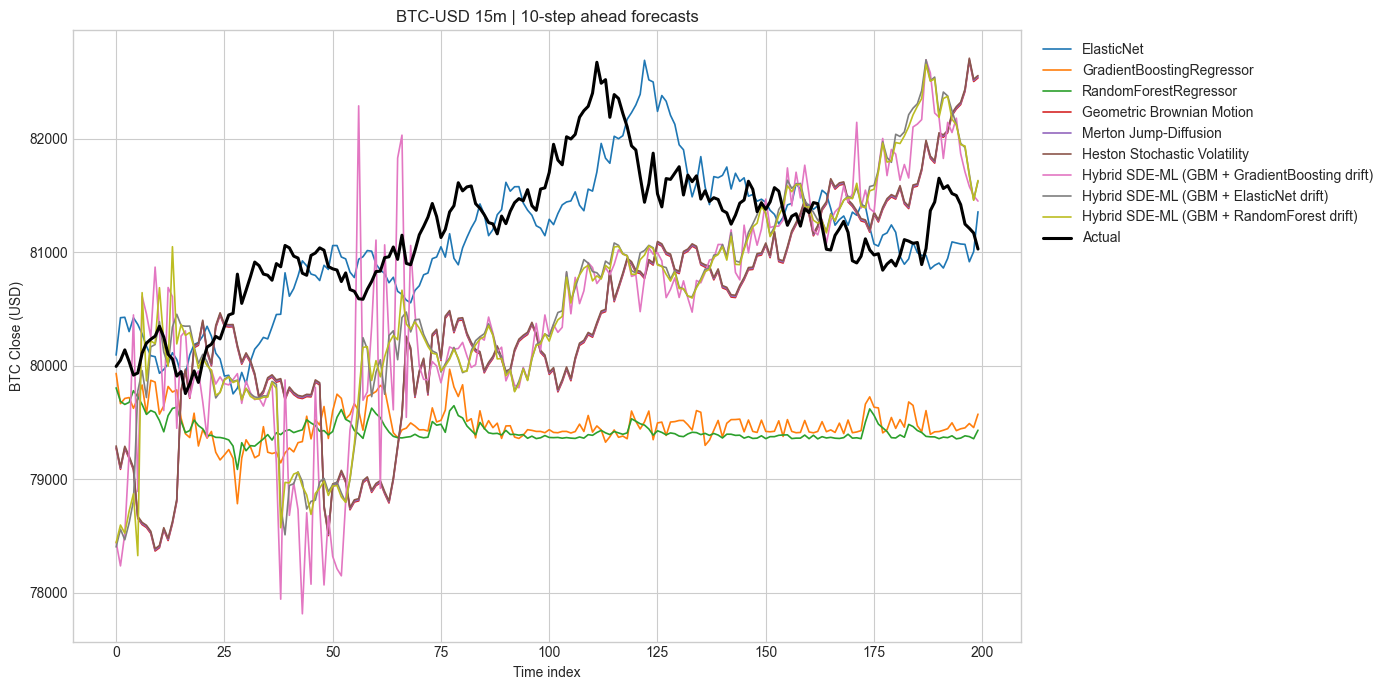

In [10]:
plt.figure(figsize=(14, 7))
for model_name, (y_true, y_pred) in predictions.items():
    plt.plot(y_pred[:200], label=model_name, linewidth=1.2)

reference_true = next(iter(predictions.values()))[0]
plt.plot(reference_true[:200], label='Actual', color='black', linewidth=2.2)
plt.title(f'BTC-USD {INTERVAL} | {HORIZON}-step ahead forecasts')
plt.xlabel('Time index')
plt.ylabel('BTC Close (USD)')
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()

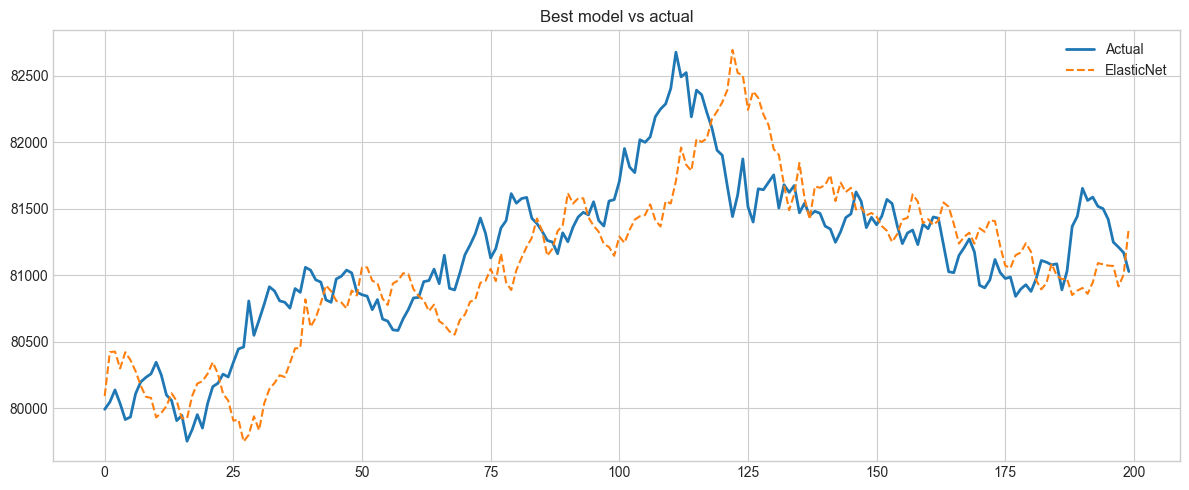

In [11]:
best_model_name = results_df.iloc[0]['model']
best_true, best_pred = predictions[best_model_name]

plt.figure(figsize=(12, 5))
plt.plot(best_true[:200], label='Actual', linewidth=2)
plt.plot(best_pred[:200], label=best_model_name, linestyle='--')
plt.title('Best model vs actual')
plt.legend()
plt.tight_layout()